In [1]:
import os
import scanpy as sc
import scvelo as scv
import matplotlib.pyplot as plt
# os.chdir("/mnt/e/project/Benchmark_velocity/revision/snRNA")
# os.getcwd()

In [2]:
data_dir = "/mnt/f/velocity_dataset_e/dataset/human_brain_sn/processed/"
fig_dir = "./figs/"
os.makedirs(fig_dir, exist_ok=True)


# 比例

In [3]:
import numpy as np
import matplotlib.pyplot as pl
import matplotlib.cm as cm
from scvelo.plotting.utils import savefig_or_show


def proportions(
    adata,
    layers=None,
    highlight="unspliced",
    add_labels_pie=True,
    fontsize=12,
    figsize=(4, 4),
    dpi=150,
    use_raw=True,
    show=True,
    save=None,
):
    """Plot only pie chart of spliced/unspliced proportions."""
    # get counts per cell for each layer
    if layers is None:
        layers = ["spliced", "unspliced", "ambiguous"]
    layers_keys = [key for key in layers if key in adata.layers.keys()]

    counts_layers = [
        np.asarray(adata.layers[key].sum(axis=1)).squeeze()  # FIX 1: 统一转为 numpy array，兼容稀疏矩阵
        for key in layers_keys
    ]

    if use_raw:
        ikey, obs = "initial_size_", adata.obs
        counts_layers = [
            np.asarray(obs[ikey + layer_key], dtype=float)  # FIX 2: 强制转为 float ndarray，避免 Series 混用
            if ikey + layer_key in obs.keys()
            else c
            for layer_key, c in zip(layers_keys, counts_layers)
        ]

    counts_total = np.sum(counts_layers, 0)
    counts_total += counts_total == 0
    counts_layers = np.array([counts / counts_total for counts in counts_layers])

    # only pie chart
    fig, ax = pl.subplots(figsize=figsize, dpi=dpi)

    # FIX 3: 使用新版 colormap API，兼容 matplotlib 3.7+
    try:
        colors = cm.get_cmap("tab20b")(np.linspace(0.10, 0.65, len(layers_keys)))
    except AttributeError:
        colors = pl.colormaps["tab20b"](np.linspace(0.10, 0.65, len(layers_keys)))

    if highlight is None:
        highlight = "none"

    # FIX 4: 区分 highlight 为字符串还是列表，避免字符串逐字符匹配
    def _is_highlighted(layer_key):
        if isinstance(highlight, str):
            return layer_key == highlight
        return layer_key in highlight

    explode = [0.1 if _is_highlighted(lk) else 0 for lk in layers_keys]

    autopct = "%1.0f%%" if add_labels_pie else None

    # FIX 5: 显式解包 pie 返回值，安全访问文本对象
    pie_result = ax.pie(
        np.mean(counts_layers, axis=1),
        colors=colors,
        explode=explode,
        autopct=autopct,
        shadow=True,
        startangle=45,
    )

    wedges = pie_result[0]
    texts = pie_result[1] if len(pie_result) > 1 else []
    autotexts = pie_result[2] if len(pie_result) > 2 else []  # autopct 文本在第三位

    if autopct is not None:
        for pct, color in zip(autotexts, colors):
            r, g, b, _ = color
            # FIX 6: 使用感知亮度公式替代乘积判断
            luminance = 0.299 * r + 0.587 * g + 0.114 * b
            pct.set_color("white" if luminance < 0.5 else "darkgrey")
            pct.set_fontweight("bold")
            pct.set_fontsize(fontsize)

    ax.legend(
        layers_keys,
        ncol=len(layers_keys),
        bbox_to_anchor=(0, 1),
        loc="lower left",
        fontsize=fontsize,
    )

    savefig_or_show("proportions", dpi=dpi, save=save, show=show)
    if show is False:
        return ax

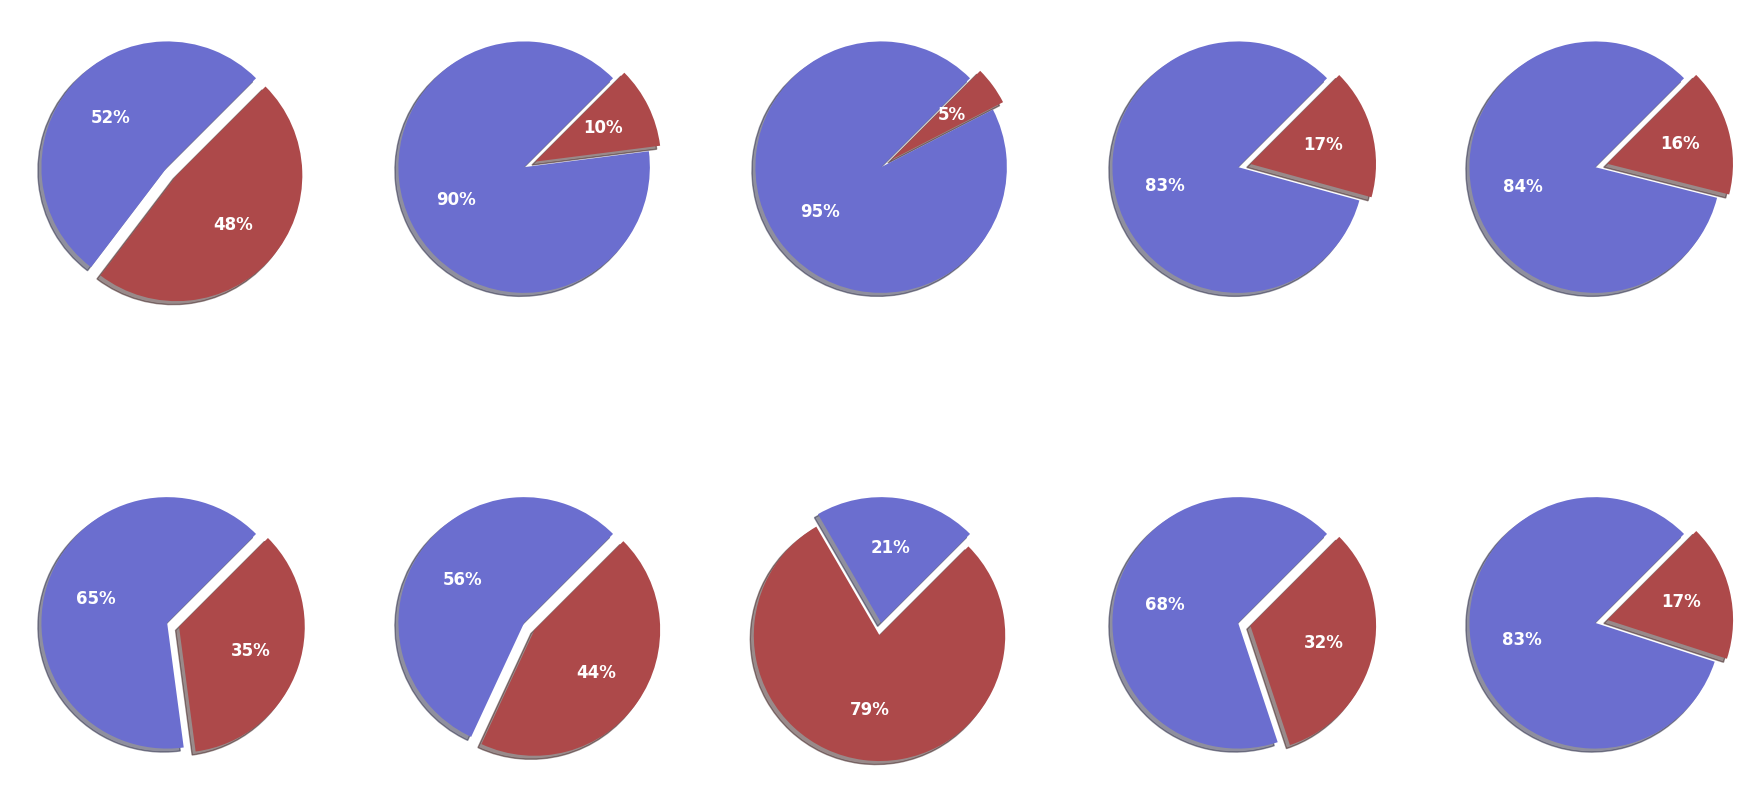

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import anndata as ad

# ── 修复后的单数据集饼图函数（绘制到指定 ax）──────────────────────────
def plot_pie_on_ax(adata, ax, title, layers=None, highlight="unspliced",
                  add_labels_pie=True, fontsize=12, use_raw=True):
    if layers is None:
        layers = ["spliced", "unspliced", "ambiguous"]
    layers_keys = [k for k in layers if k in adata.layers.keys()]

    counts_layers = [
        np.asarray(adata.layers[k].sum(axis=1)).squeeze()
        for k in layers_keys
    ]
    if use_raw:
        ikey, obs = "initial_size_", adata.obs
        counts_layers = [
            np.asarray(obs[ikey + lk], dtype=float)
            if ikey + lk in obs.keys() else c
            for lk, c in zip(layers_keys, counts_layers)
        ]

    counts_total = np.sum(counts_layers, 0)
    counts_total += counts_total == 0
    counts_layers = np.array([c / counts_total for c in counts_layers])

    try:
        colors = cm.get_cmap("tab20b")(np.linspace(0.10, 0.65, len(layers_keys)))
    except AttributeError:
        colors = plt.colormaps["tab20b"](np.linspace(0.10, 0.65, len(layers_keys)))

    if highlight is None:
        highlight = "none"

    def _is_highlighted(lk):
        return lk == highlight if isinstance(highlight, str) else lk in highlight

    explode = [0.1 if _is_highlighted(lk) else 0 for lk in layers_keys]
    autopct = "%1.0f%%" if add_labels_pie else None

    pie_result = ax.pie(
        np.mean(counts_layers, axis=1),
        colors=colors,
        explode=explode,
        autopct=autopct,
        shadow=True,
        startangle=45,
    )
    autotexts = pie_result[2] if len(pie_result) > 2 else []
    if autopct is not None:
        for pct, color in zip(autotexts, colors):
            r, g, b, _ = color
            luminance = 0.299 * r + 0.587 * g + 0.114 * b
            pct.set_color("white" if luminance < 0.5 else "darkgrey")
            pct.set_fontweight("bold")
            pct.set_fontsize(fontsize)

    # ax.set_title(title, fontsize=14, pad=6)


# ── 数据集路径与标题 ──────────────────────────────────────────────────
datasets = [
    ("/mnt/f/velocity_dataset_e/dataset/human_bone_marrow/raw/human_bone_marrow.h5ad",            "Bone marrow"),
    ("/mnt/f/velocity_dataset_e/dataset/dentate_gyrus/raw/dentate_gyrus.h5ad",                    "Dentate gyrus"),
    ("/mnt/f/velocity_dataset_e/dataset/gastrulation_erythroid/raw/gastrulation_erythroid.h5ad",  "Gastrulation erythroid"),
    ("/mnt/f/velocity_dataset_e/dataset/pancreatic_endocrinogenesis/raw/pancreatic_endocrinogenesis.h5ad", "Pancreas"),
    ("/mnt/f/velocity_dataset_e/dataset/pan4time/raw/pan4time_after.h5ad", "Pancreas"),
    ("/mnt/f/velocity_dataset_e/dataset/HSPCs/raw/adata_after.h5ad",                              "HSPCs"),
    ("/mnt/f/velocity_dataset_e/dataset/human_brain_rna/raw/human_brain.h5ad",                            "Brain"),
    ("/mnt/f/velocity_dataset_e/dataset/human_brain_sn/processed/adata_preprocessed_full.h5ad",   "Brain"),
    ("/mnt/f/velocity_dataset_e/dataset/intestinal_organoid/raw/intestinal_organoid.h5ad",         "Intestinal organoid"),
    ("/mnt/f/velocity_dataset_e/dataset/KCl_stimulation/raw/KCl_stimulation.h5ad",                "Cortical neuron"),
]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()
adatas = []
for ax, (path, title) in zip(axes, datasets):
    adata = ad.read_h5ad(path)
    adatas.append(adata)
    plot_pie_on_ax(adata, ax, title=title, layers=['spliced', 'unspliced'])

# axes[-1].set_visible(False)  # ← 加这一行，第10个子图完全空白

plt.tight_layout()
fig.subplots_adjust(hspace=0.45)
plt.savefig(f"{fig_dir}proportions_datas.png", bbox_inches="tight", dpi=150)
plt.show()